This script allows us to test if the manipulation of green plants works. The greenness of each image was calculated in compute_greenness.py.

In [2]:
# import the libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from evaluate_luminance import df_luminance

In [3]:
# load the experimental data, re-categorize it and drop the duplicates
df_subjects = pd.read_excel("Data_exp1.xlsx")
df_subjects['Category'] = np.where(df_subjects['PredHominess'] == 'Plus', 'Plus', df_subjects['Dimension'])
mapping = {
    'Plus': 'Combined+',
    'Ceiling': 'Ceiling-',
    'Lighting': 'Lighting-',
    'Biophilic': 'Biophilic-',
    'Combined': 'Combined-'
}
df_subjects['Category'] = df_subjects['Category'].map(mapping)
df_info = df_subjects[["ImageNumber", "Category"]].drop_duplicates()
# load the image information
df_images = pd.read_csv("Image_greenness.csv")

In [4]:
# quick check
df_images.head()

,ImageNumber,ImageName,Greenness
0,1,1.jpeg,0.000000
1,2,2.jpeg,0.064579
2,3,3.jpeg,0.027116
3,4,4.jpeg,0.034674
4,5,5.jpeg,0.004193


In [5]:
# combine the two data frames
df_greenness = pd.merge(df_images, df_info, on="ImageNumber", how="left")
df_greenness.set_index('ImageNumber', inplace=True)
df_greenness

,ImageName,Greenness,Category
ImageNumber,,,
1,1.jpeg,0.000000,Combined+
2,2.jpeg,0.064579,Combined+
3,3.jpeg,0.027116,Combined+
4,4.jpeg,0.034674,Combined+
5,5.jpeg,0.004193,Combined+
...,...,...,...
156,156.jpeg,0.000014,Combined-
157,157.jpeg,0.000080,Combined-
158,158.jpeg,0.000067,Combined-


In [6]:
# Statistics
df_greenness.groupby("Category")["Greenness"].describe()

,count,mean,std,min,25%,50%,75%,max
Category,,,,,,,,
Biophilic-,20.0,0.003288,0.005991,0.0,0.000040,0.000408,0.003036,0.023622
Ceiling-,20.0,0.012032,0.028737,0.0,0.000026,0.002986,0.012263,0.128915
Combined+,80.0,0.026315,0.030291,0.0,0.001256,0.011671,0.043997,0.136849
Combined-,20.0,0.004351,0.017543,0.0,0.000009,0.000044,0.000307,0.078753
Lighting-,20.0,0.000735,0.001803,0.0,0.000002,0.000010,0.000216,0.006344


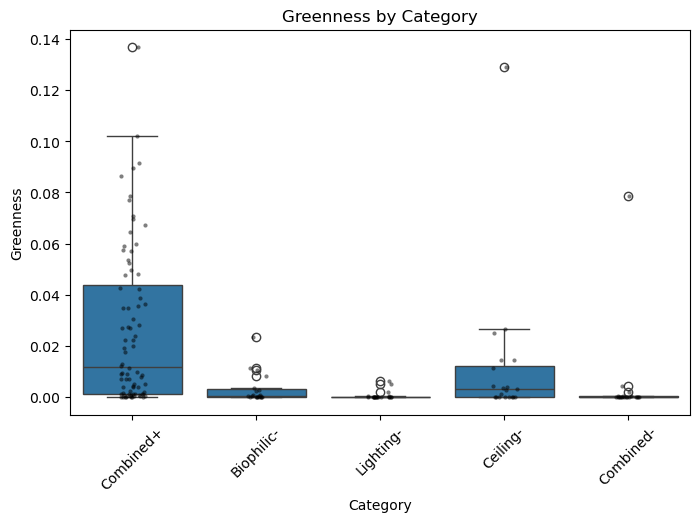

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


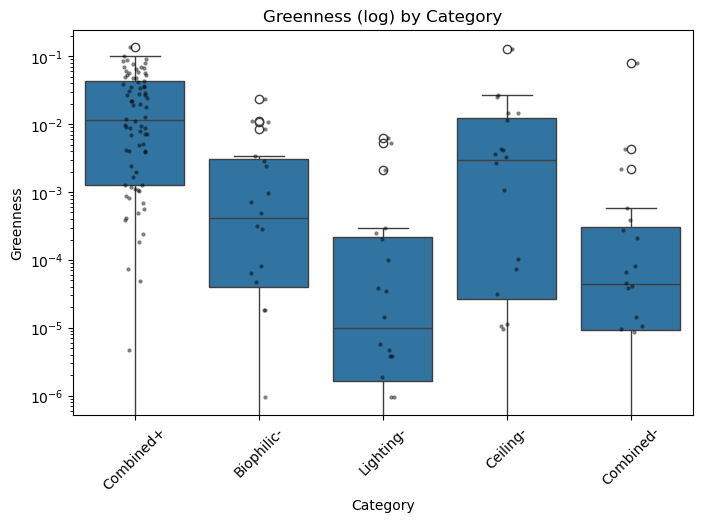

In [8]:
# Plots
# Raw data
plt.figure(figsize=(8,5))
sns.boxplot(x="Category", y="Greenness", data=df_greenness)
sns.stripplot(x="Category", y="Greenness", data=df_greenness, color="black", size=3, alpha=0.5)
plt.title("Greenness by Category")
plt.xticks(rotation=45)
plt.show()

# Log-scale y-axis to make it more clear
plt.figure(figsize=(8,5))
sns.boxplot(x="Category", y="Greenness", data=df_greenness)
sns.stripplot(x="Category", y="Greenness", data=df_greenness, color="black", size=3, alpha=0.5)
plt.title("Greenness (log) by Category")
plt.xticks(rotation=45)
plt.yscale("log")
# Save as PDF vector format for journals
plt.savefig(
    "Figure7a.pdf",
    dpi=600,
    format="pdf",
    bbox_inches="tight",
)

# Save as EPS vector format for journals
plt.savefig(
    "Figure7a.eps",
    dpi=600,
    format="eps",
    bbox_inches="tight",
)

plt.show()


In [14]:
# Hypothesis testing
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# one-way ANOVA
model = ols("Greenness ~ C(Category)", data=df_greenness).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("=== One-way ANOVA ===")
print(anova_table)

# Post hoc (Tukey HSD)
print("\n=== Tukey HSD (post-hoc) ===")
tukey = pairwise_tukeyhsd(endog=df_greenness["Greenness"],
                          groups=df_greenness["Category"],
                          alpha=0.05)
print(tukey)


=== One-way ANOVA ===
               sum_sq     df         F    PR(>F)
C(Category)  0.019420    4.0  7.940815  0.000008
Residual     0.094769  155.0       NaN       NaN

=== Tukey HSD (post-hoc) ===
    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1     group2  meandiff p-adj   lower   upper  reject
-----------------------------------------------------------
Biophilic-  Ceiling-   0.0087 0.7968 -0.0128  0.0303  False
Biophilic- Combined+    0.023 0.0025   0.006  0.0401   True
Biophilic- Combined-   0.0011 0.9999 -0.0205  0.0226  False
Biophilic- Lighting-  -0.0026 0.9975 -0.0241   0.019  False
  Ceiling- Combined+   0.0143  0.147 -0.0028  0.0313  False
  Ceiling- Combined-  -0.0077 0.8629 -0.0293  0.0139  False
  Ceiling- Lighting-  -0.0113 0.5998 -0.0329  0.0103  False
 Combined+ Combined-   -0.022 0.0045  -0.039 -0.0049   True
 Combined+ Lighting-  -0.0256 0.0005 -0.0426 -0.0085   True
 Combined- Lighting-  -0.0036 0.9905 -0.0252   0.018  False
---------------------

In [15]:
# Hypothesis testing using log-tranformed values
df_greenness['log_greenness'] = np.log1p(df_greenness['Greenness'])
# one-way ANOVA
model = ols("log_greenness ~ C(Category)", data=df_greenness).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("=== One-way ANOVA ===")
print(anova_table)

# Post hoc (Tukey HSD)
print("\n=== Tukey HSD (post-hoc) ===")
tukey = pairwise_tukeyhsd(endog=df_greenness["log_greenness"],
                          groups=df_greenness["Category"],
                          alpha=0.05)
print(tukey)


=== One-way ANOVA ===
               sum_sq     df         F    PR(>F)
C(Category)  0.018290    4.0  8.191509  0.000005
Residual     0.086521  155.0       NaN       NaN

=== Tukey HSD (post-hoc) ===
    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1     group2  meandiff p-adj   lower   upper  reject
-----------------------------------------------------------
Biophilic-  Ceiling-   0.0083 0.7982 -0.0123   0.029  False
Biophilic- Combined+   0.0223 0.0021   0.006  0.0386   True
Biophilic- Combined-   0.0009 0.9999 -0.0197  0.0216  False
Biophilic- Lighting-  -0.0025 0.9971 -0.0232  0.0181  False
  Ceiling- Combined+    0.014 0.1313 -0.0023  0.0303  False
  Ceiling- Combined-  -0.0074 0.8595  -0.028  0.0132  False
  Ceiling- Lighting-  -0.0109 0.5935 -0.0315  0.0098  False
 Combined+ Combined-  -0.0214 0.0037 -0.0377  -0.005   True
 Combined+ Lighting-  -0.0248 0.0004 -0.0411 -0.0085   True
 Combined- Lighting-  -0.0035 0.9904 -0.0241  0.0172  False
---------------------

Our hypothesis is that greenness is close to biophilic-. It's true that the greenness values of biophilic- (remove this dimension) and combined- (remove all dimensions) images are significantly lower that those of combined+ images and there's no difference between combined+ and ceiling- images. However, the greenness of lighting- images is also lower than that of combined+ images. This is exactly what we were worried about —— the removal of lighting leads to the decrease of greenness.

In [10]:
# save it for analysis in JASP so that we can easily have all statistics (p values, effect sizes, tec.)
df_luminance = pd.read_csv("Image_luminance.csv").set_index("ImageNumber")
df_com = pd.concat([df_greenness, df_luminance['Luminance']], axis=1)
df_com.head()
df_com.to_csv('Image_info.csv')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


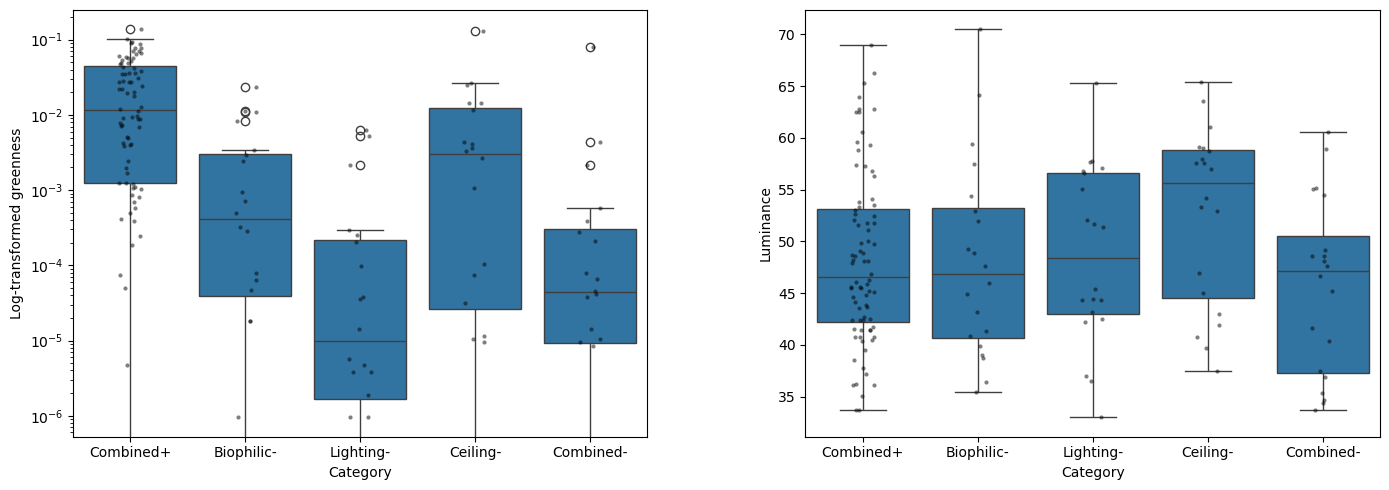

In [12]:
# set the figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 2. Log-greenness
sns.boxplot(data=df_com, x='Category', y='Greenness', ax=axes[0])
sns.stripplot(x="Category", y="Greenness", data=df_com, color="black", size=3, alpha=0.5, ax=axes[0])
#axes[0].set_title('1a: Log-transformed greenness by Category')
axes[0].set_yscale("log")
#axes[0].tick_params(axis='x', rotation=45)
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Log-transformed greenness')



# Luminance
sns.boxplot(data=df_com, x='Category', y='Luminance', ax=axes[1])
sns.stripplot(x="Category", y="Luminance", data=df_com, color="black", size=3, alpha=0.5, ax=axes[1])
#axes[1].set_title('1b: Luminance by Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Luminance')


plt.tight_layout(w_pad=8)
# Save as PDF vector format for journals
plt.savefig(
    "Figure7.pdf",
    dpi=600,
    format="pdf",
    bbox_inches="tight",
)

# Save as EPS vector format for journals
plt.savefig(
    "Figure7.eps",
    dpi=600,
    format="eps",
    bbox_inches="tight",
)
plt.show()
# plt.savefig('comparison_plots.png')